In [123]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import gaussian_kde
from models import CondSM
from utils import f_sm, sample_X, mse_loss_normalized, normalize_over_range


latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

import matplotlib.pyplot as plt
import numpy as np

def make_gate_template(figsize=(6,4)):
    fig = plt.figure(figsize=figsize)

    # Fixed axes rectangles in figure coordinates: [left, bottom, width, height]
    ax0 = fig.add_axes([0.15, 0.72, 0.80, 0.20])  # V0
    ax1 = fig.add_axes([0.15, 0.47, 0.80, 0.20])  # V1
    ax2 = fig.add_axes([0.15, 0.15, 0.80, 0.28])  # Iout (with xticks/labels)

    axes = [ax0, ax1, ax2]

    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    style_axis(ax0, "$V_0$")
    style_axis(ax1, "$V_1$")
    style_axis(ax2, "$I_{\\mathrm{out}} \\quad [nA]$")

    return fig, axes

def clear_axes_keep_layout(axes):
    # clears plotted data but keeps axes objects/positions
    for ax in axes:
        ax.cla()

def restyle_after_clear(axes):
    # re-apply your styling after cla()
    labels = ["$V_0$", "$V_1$", "$I_{\\mathrm{out}} \\quad [nA]$"]
    for ax, lab in zip(axes, labels):
        ax.set_ylabel(lab, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

def draw_gate_on_axes(axes, gate_inputs, currents, sem=None, label=None, ls="-", lw=2, show_legend=False):
    in_0 = [gi[0] for gi in gate_inputs]
    in_1 = [gi[1] for gi in gate_inputs]
    y = np.asarray(currents, float).reshape(-1)

    t = np.arange(len(gate_inputs) + 1)

    # inputs
    axes[0].step(t, np.r_[in_0, in_0[-1]], where="post", lw=2)
    axes[1].step(t, np.r_[in_1, in_1[-1]], where="post", lw=2)

    # output
    axes[2].step(t, np.r_[y, y[-1]], where="post", lw=lw, ls=ls, label=label)

    if sem is not None:
        sem = np.asarray(sem, float).reshape(-1)
        lo = np.r_[y - sem, (y - sem)[-1]]
        hi = np.r_[y + sem, (y + sem)[-1]]
        axes[2].fill_between(t, lo, hi, step="post", alpha=0.25)

    centers = np.arange(len(gate_inputs)) + 0.5
    state_labels = ["00", "01", "10", "11"][:len(gate_inputs)]
    axes[2].set_xticks(centers)
    axes[2].set_xticklabels(state_labels)
    axes[2].set_xlabel("Input $V_0, V_1 \\quad [V]$")

    if show_legend:
        axes[2].legend(frameon=False, loc="best")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print('Libraries loaded')

e_0 = 1.60217663e-19
time_scale = 1e21
out_scale = e_0 * time_scale

cuda
Libraries loaded


In [100]:
data_type = 'data_vMB_ring_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

input_index = 3
print("Model loaded")

Model loaded


In [106]:
def mse_loss_normalized(x, y):

    x = x.float()
    y = y.float()
    x_norm = (x - x.mean()) / (x.std(unbiased=False) + 1e-8)
    y_norm = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)
    
    mse = torch.mean((y_norm - x_norm)**2).item()

    return mse

def target_function(x):

    m = nn.Sigmoid()
    #return m(5*x)
    #return -torch.exp(-1*x**2)#m(x)#torch.sigmoid(5*x)
    #return np.sqrt(1 + (5*x) ** 2)
    #return np.sin(2*x)
    return x ** 1

def normalize_over_range(x):
    
    z = (x - x.mean()) / (x.std() + 1e-8) 
    
    return z

num_curve_points = 50
num_voltages = 7
control_indices = [c_index for c_index in range(num_voltages) if c_index != input_index]
print(control_indices)
v_min = -1.5
v_max = 1.5
curve_range = torch.linspace(v_min, v_max, num_curve_points)
target_input_range = torch.linspace(v_min, v_max, num_curve_points).unsqueeze(1)
target = target_function(target_input_range)

[0, 1, 2, 4, 5, 6]


In [107]:
import torch

num_samples = 100_000
c_v_min, c_v_max = -1.5, 1.5
theta_samples_np = sample_X(num_samples, c_v_min, c_v_max, d=6)

model = model.to(device).eval()

# --- move constants to device once ---
control_indices_t = torch.tensor(control_indices, device=device, dtype=torch.long)
curve_range_t = torch.as_tensor(curve_range, device=device, dtype=torch.float32)  # [num_curve_points]
target_t = target.to(device) if isinstance(target, torch.Tensor) else torch.as_tensor(target, device=device)

# theta samples on GPU once
theta = torch.from_numpy(theta_samples_np).to(device=device, dtype=torch.float32)  # [S, d]

# Prebuild a "base" input for a single sample: [P, V]
base = torch.zeros(num_curve_points, num_voltages, device=device, dtype=torch.float32)
base[:, input_index] = curve_range_t

batch_size = 2*4096  # try 256/512/1024 depending on VRAM
scores = torch.empty(num_samples, device=device, dtype=torch.float32)

mse = mse_loss_normalized  # keep your function

with torch.inference_mode():
    for start in range(0, num_samples, batch_size):
        end = min(start + batch_size, num_samples)
        B = end - start

        # Build batch input: [B, P, V] by expanding base
        x = base.unsqueeze(0).expand(B, -1, -1).clone()

        # Put controls in: theta[start:end] is [B, d]
        # Expand to [B, P, d], then assign into voltage columns
        controls = theta[start:end].unsqueeze(1).expand(-1, num_curve_points, -1)
        x.index_copy_(2, control_indices_t, controls)  # write d columns at once
        #print(x)

        # If model expects 2D points, flatten to [B*P, V]
        x2d = x.reshape(-1, num_voltages)

        y = model(x2d)  # whatever output shape your model produces per point

        # You likely need to reshape y back per-sample before scoring
        # Example if y is [B*P, out_dim] -> [B, P, out_dim]
        y = y.reshape(B, num_curve_points, *y.shape[1:])

        # Compute per-sample fitness
        # If your mse_loss_normalized returns a scalar for one sample,
        # you can vectorize it; otherwise loop *inside the batch* (much cheaper).
        # Here’s a safe fallback loop inside batch:
        for i in range(B):
            #print(y[i].shape)
            scores[start + i] = mse(y[i].detach().cpu(), target)  # adjust if mse expects tensors on CPU/GPU

# move back to CPU for Python ops
scores_cpu = scores.detach().cpu().tolist()
min_score = min(scores_cpu)
max_score = max(scores_cpu)
max_index = scores_cpu.index(max_score)
min_index = scores_cpu.index(min_score)

print(max_index)
print(min_score)
print(max_score)
print(theta_samples_np[min_index].tolist())
print("Done")

43510
3.7986224924679846e-05
3.9984254837036133
[0.8753402530922632, -1.0253061239863164, -1.422887499677454, 0.3632564603904136, -0.5936841118833686, -0.4706212141182309]
Done


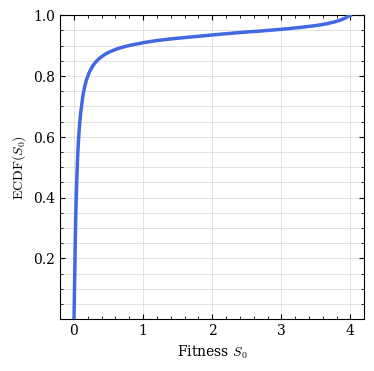

In [108]:
scores = scores.cpu()
s = np.asarray(scores[:50_000], float)
s = s[np.isfinite(s)]
s_sorted = np.sort(s)
n = len(s_sorted)

ecdf = np.arange(1, n+1) / n
ccdf = 1 - ecdf

fig, ax = plt.subplots(figsize=(4,4))
ax.set_position([0.18, 0.12, 0.76, 0.83])
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(which='both', direction='in')

#ax.plot(s_sorted, ccdf, lw=2.5, zorder=6, c='royalblue')
#ax.set_yscale('log')
#ax.set_ylabel(r'$1-\mathrm{ECDF}(S_0)$')
ax.set_ylabel(r'$\mathrm{ECDF}(S_0)$')
ax.set_ylim(1/n, 1)  # avoid 0 on log scale
ax.plot(s_sorted, ecdf, lw=2.5, zorder=6, c='royalblue')

ax.grid(lw=0.5, alpha=0.5, which='major')
ax.grid(lw=0.5, alpha=0.5, which='minor', axis='y')

ax.set_xlabel(r'Fitness $S_0$')
ax.set_box_aspect(1)

#fig.savefig(f'data_type={data_type}_func={func_target}.pdf')

3.9984254837036133
Controls: tensor([ 0.8753, -1.0253, -1.4229,  0.3633, -0.5937, -0.4706])
[-9.99999000e+02  0.00000000e+00  8.75340253e-01 -9.99999000e+02
 -1.42288750e+00  3.63256460e-01 -5.93684112e-01 -4.70621214e-01]


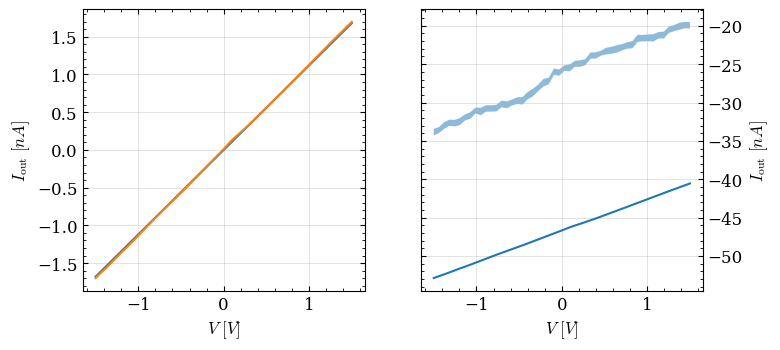

In [131]:
fig, ax = plt.subplots(ncols=2, figsize=(8,4))

ax_1 = ax[0]
ax_2 = ax[1]

print(max_score)
controls = torch.tensor(theta_samples_np[min_index].tolist()).expand(n_points, -1)
print("Controls:", controls[0, :])

control_indices = [i for i in range(num_voltages) if i != input_index]
#print(control_indices)
input_range = torch.linspace(v_min, v_max, n_points).unsqueeze(0)

input_tensor = torch.zeros(n_points, num_voltages)
input_tensor[:, input_index] = input_range
for j, k in enumerate(control_indices):
    input_tensor[:, k] = controls[:, j]
input_tensor = input_tensor.to(device)
model.eval()
with torch.no_grad():
    y_out = model(input_tensor).detach().cpu().numpy().squeeze()

ax_1.plot(input_range.squeeze(), normalize_over_range(target_function(input_range).squeeze()))
ax_1.set_box_aspect(1)
ax_1.minorticks_on()
ax_1.tick_params(direction='in', which='both')
ax_1.tick_params(top=True, right=True, which='both')
ax_1.grid(lw=0.5, alpha=0.5)
ax_1.set_xlabel(r'$V \, \, [V]$')
ax_1.set_ylabel(r'$I_{\mathrm{out}} \, \, [nA]$')

ax_1.plot(input_range.squeeze(), normalize_over_range(y_out))

data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/found_1d_functions/opt_type=random_func_type=linear_data_type=data_vMB_ring_1e7.npz')
print(data['control'])
I_controls = data['control']
I_out = data['current'] * time_scale
I_err = data['sem'] * time_scale
n_points = I_out.shape[0]
ax_2.fill_between(input_range.squeeze(), I_out - 1.96*I_err, I_out + 1.96*I_err, alpha=0.5)
ax_2.plot(input_range.squeeze(), y_out)
ax_2.set_box_aspect(1)
ax_2.minorticks_on()
ax_2.tick_params(direction='in', which='both')
ax_2.tick_params(top=True, right=True, which='both')
ax_2.grid(lw=0.5, alpha=0.5)
ax_2.tick_params(labelleft=False, labelright=True)
ax_2.set_ylabel(r'$I_{\mathrm{out}} \, \, [nA]$')
ax_2.set_xlabel(r'$V \, \, [V]$')
ax_2.yaxis.set_label_position('right')